In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn as sk
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import streamlit as st

df = pd.read_csv(r"C:\Users\Alhar\Downloads\Lifestyle_and_Health_Risk_Prediction_Synthetic_Dataset.csv")
df.head()

,age,weight,height,exercise,sleep,sugar_intake,smoking,alcohol,married,profession,bmi,health_risk
0,56,67,195,low,6.1,medium,yes,yes,yes,office_worker,17.6,high
1,69,76,170,high,6.9,high,no,no,no,teacher,26.3,high
2,46,106,153,high,6.6,low,yes,no,no,artist,45.3,high
3,32,54,186,medium,8.5,medium,no,no,no,artist,15.6,low
4,60,98,195,high,8.0,low,no,no,yes,teacher,25.8,high


In [33]:
df = df.drop(columns=["alcohol",
                      "height",
                      "weight"])

In [34]:
df.head()

,age,exercise,sleep,sugar_intake,smoking,married,profession,bmi,health_risk
0,56,low,6.1,medium,yes,yes,office_worker,17.6,high
1,69,high,6.9,high,no,no,teacher,26.3,high
2,46,high,6.6,low,yes,no,artist,45.3,high
3,32,medium,8.5,medium,no,no,artist,15.6,low
4,60,high,8.0,low,no,yes,teacher,25.8,high


In [35]:
df.shape

(5000, 9)

In [36]:
df.describe([0.10,0.25,0.50,0.75,0.90,0.95,0.99]).T

,count,mean,std,min,10%,25%,50%,75%,90%,95%,99%,max
age,5000.0,48.80560,17.906991,18.0,24.0,34.0,49.0,64.0,74.00,77.0,79.0,79.0
sleep,5000.0,6.99706,1.432849,3.0,5.2,6.0,7.0,8.0,8.90,9.5,10.0,10.0
bmi,5000.0,26.84388,8.252490,11.4,16.7,20.3,26.0,32.4,38.21,41.9,47.7,51.4


In [37]:
df["health_risk"].value_counts()*100/len(df)

health_risk
high    69.8
low     30.2
Name: count, dtype: float64

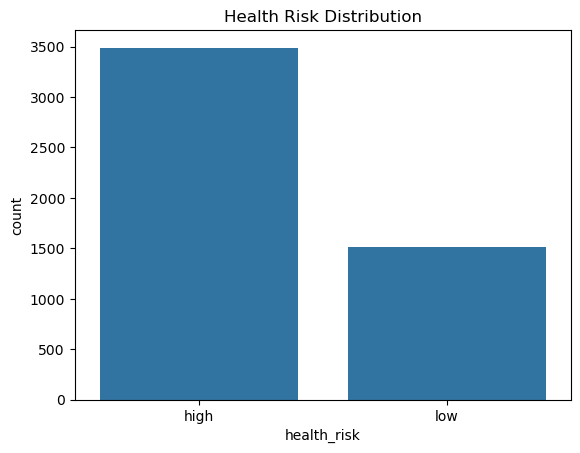

In [44]:
sns.countplot(x='health_risk', data=df)

plt.title("Health Risk Distribution")
plt.show()

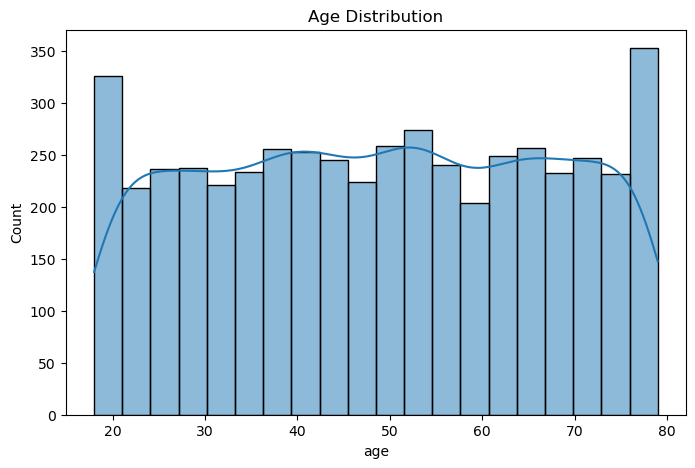

In [45]:
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.show()

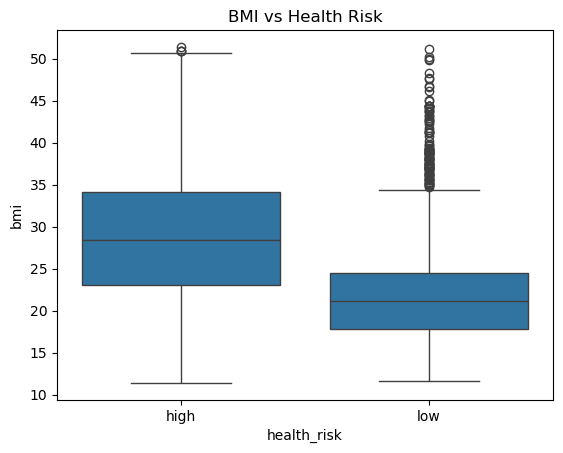

In [40]:
sns.boxplot(
    x='health_risk',
    y='bmi',
    data=df
)

plt.title("BMI vs Health Risk")
plt.show()

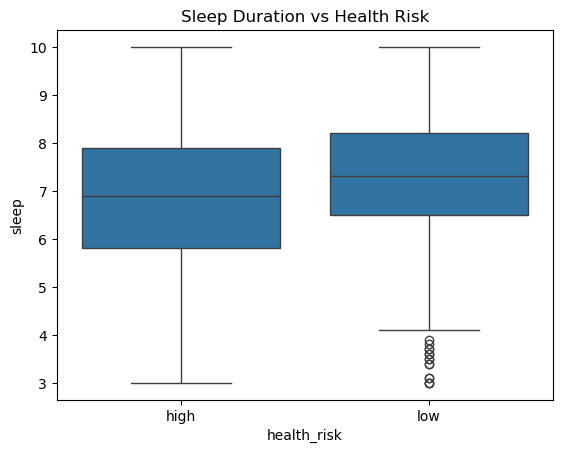

In [47]:
sns.boxplot(
    x='health_risk',
    y='sleep',
    data=df
)

plt.title("Sleep Duration vs Health Risk")
plt.show()

In [48]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           5000 non-null   int64  
 1   exercise      5000 non-null   object 
 2   sleep         5000 non-null   float64
 3   sugar_intake  5000 non-null   object 
 4   smoking       5000 non-null   object 
 5   married       5000 non-null   object 
 6   profession    5000 non-null   object 
 7   bmi           5000 non-null   float64
 8   health_risk   5000 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 351.7+ KB


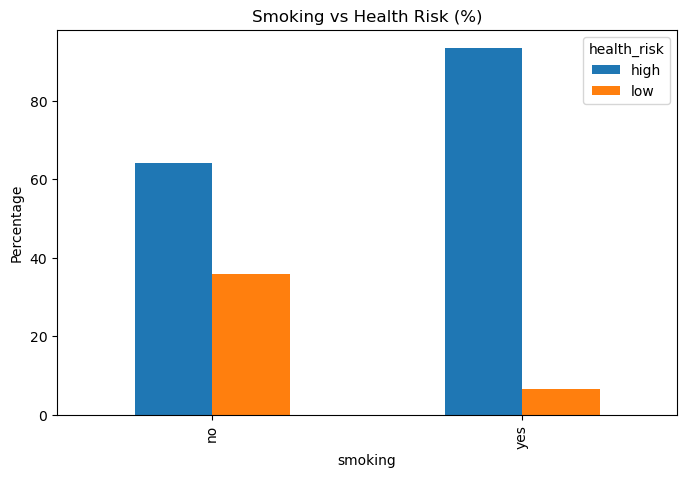

In [52]:
smoking_risk = pd.crosstab(
    df['smoking'],
    df['health_risk'],
    normalize='index'
) * 100

smoking_risk.plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Smoking vs Health Risk (%)")
plt.ylabel("Percentage")
plt.show()

In [60]:
le = LabelEncoder()

categorical_columns = [
    'exercise',
    'sugar_intake',
    'smoking',
    'married',
    'profession',
    'health_risk'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])


In [61]:
X = df.drop('health_risk', axis=1)

y = df['health_risk']

# 80% تدريب - 20% اختبار
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [62]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [63]:
y_pred = model.predict(X_test)

In [64]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.828

Confusion Matrix:

[[633  75]
 [ 97 195]]

Classification Report:

              precision    recall  f1-score   support

           0       0.87      0.89      0.88       708
           1       0.72      0.67      0.69       292

    accuracy                           0.83      1000
   macro avg       0.79      0.78      0.79      1000
weighted avg       0.82      0.83      0.83      1000



In [65]:
from sklearn.ensemble import RandomForestClassifier

# إنشاء النموذج
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# تدريب النموذج
rf_model.fit(X_train, y_train)

# التنبؤ
rf_pred = rf_model.predict(X_test)

# التقييم
print("Accuracy:", accuracy_score(y_test, rf_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, rf_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, rf_pred))

Accuracy: 0.931

Confusion Matrix:

[[665  43]
 [ 26 266]]

Classification Report:

              precision    recall  f1-score   support

           0       0.96      0.94      0.95       708
           1       0.86      0.91      0.89       292

    accuracy                           0.93      1000
   macro avg       0.91      0.93      0.92      1000
weighted avg       0.93      0.93      0.93      1000



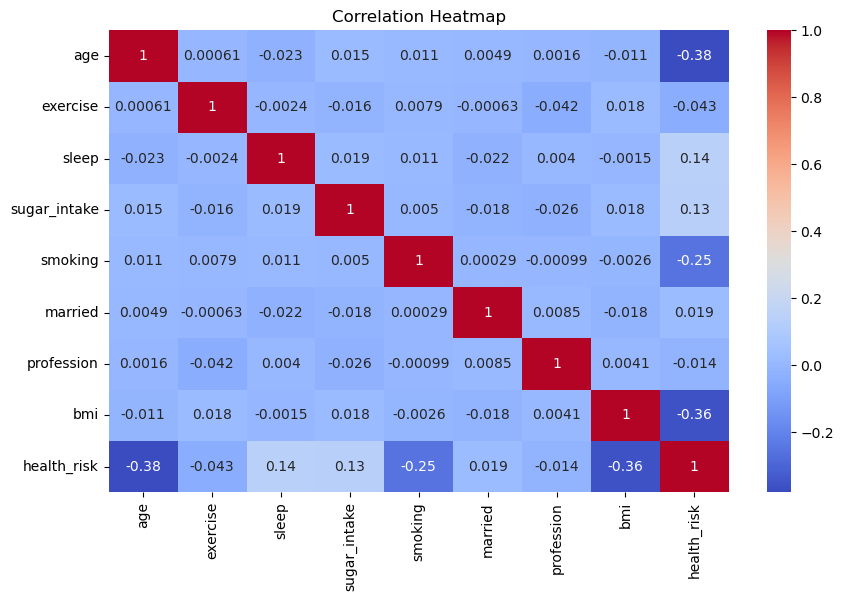

In [66]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")
plt.show()

        Feature  Importance
7           bmi    0.301553
0           age    0.294599
2         sleep    0.112113
1      exercise    0.103333
4       smoking    0.084994
3  sugar_intake    0.053032
6    profession    0.040106
5       married    0.010271


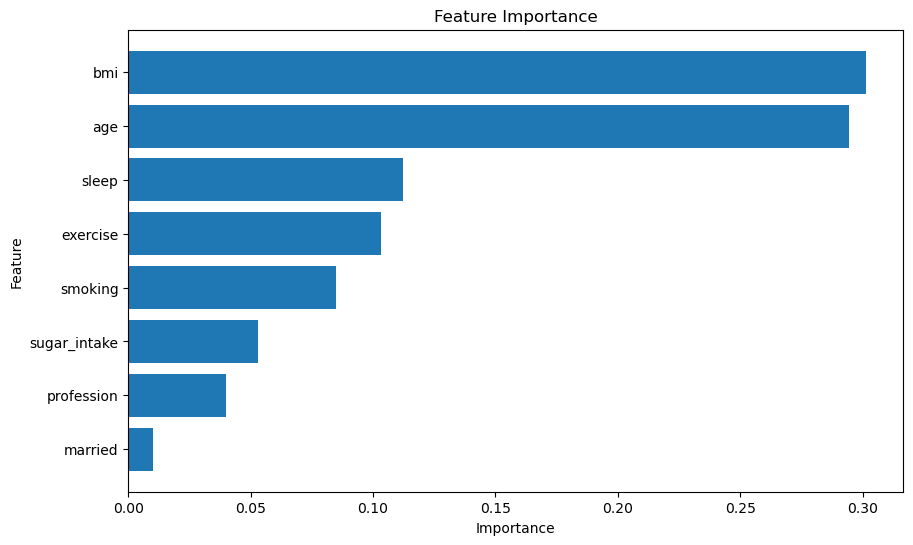

In [72]:
importance = rf_model.feature_importances_

features = X.columns

feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print(feature_importance)

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance['Feature'],
    feature_importance['Importance']
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance")

plt.gca().invert_yaxis()

plt.show()

In [73]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    rf_model,
    X,
    y,
    cv=5
)

print(scores)
print("Average Accuracy:", scores.mean())

[0.946 0.924 0.923 0.929 0.928]
Average Accuracy: 0.93


In [74]:
import numpy as np
from sklearn.model_selection import KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

# X = features
# y = target (life style risk: 0 / 1)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)

# K-Fold setup
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Cross validation (accuracy)
scores = cross_val_score(model, X, y, cv=kf, scoring='accuracy')

print("Scores for each fold:", scores)
print("Mean Accuracy:", scores.mean())
print("Std:", scores.std())

Scores for each fold: [0.926 0.922 0.931 0.93  0.935]
Mean Accuracy: 0.9288000000000001
Std: 0.004445222154178577


In [75]:
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_predict

y_pred = cross_val_predict(model, X, y, cv=kf)

print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      3490
           1       0.88      0.89      0.88      1510

    accuracy                           0.93      5000
   macro avg       0.91      0.92      0.92      5000
weighted avg       0.93      0.93      0.93      5000

